# Used Car Price Analysis & Prediction
Exploring 4,000+ used car listings: what drives price, and how well can we predict it?

**Sections:**
1. Load & clean data
2. Exploratory analysis (brand, mileage, accidents)
3. Predictive model (Random Forest)
4. Visualization

## 1. Load & clean data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

%matplotlib inline
df = pd.read_csv('used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [2]:
# Strip "$" and "," from price -> float
df['price_num'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

# Strip "mi." and "," from mileage -> float
df['mileage_num'] = df['milage'].replace(r'[a-zA-Z. ,]', '', regex=True).astype(float)

# Drop extreme outliers (ultra-luxury cars skew price stats/model heavily)
df_clean = df[df['price_num'] < 400_000].copy()

print('Full dataset shape:', df.shape)
print('Clean dataset shape:', df_clean.shape)

Full dataset shape: (4009, 14)
Clean dataset shape: (3990, 14)


## 2. Exploratory analysis

In [3]:
df_clean[['price_num', 'mileage_num', 'model_year']].describe()

,price_num,mileage_num,model_year
count,3990.000000,3990.000000,3990.000000
mean,41035.996992,64998.656642,2015.511278
std,40171.310546,52259.544601,6.106127
min,2000.000000,100.000000,1974.000000
25%,17000.000000,23294.000000,2012.000000
50%,31000.000000,53134.500000,2017.000000
75%,49663.500000,94411.000000,2020.000000
max,399950.000000,405000.000000,2024.000000


In [4]:
top_brands = df_clean['brand'].value_counts().head(10).index
df_clean['brand'].value_counts().head(10)

brand
Ford             385
BMW              375
Mercedes-Benz    314
Chevrolet        292
Audi             200
Toyota           199
Porsche          198
Lexus            163
Jeep             143
Land             130
Name: count, dtype: int64

In [5]:
avg_price_by_brand = (
    df_clean[df_clean['brand'].isin(top_brands)]
    .groupby('brand')['price_num']
    .mean()
    .sort_values(ascending=False)
)
avg_price_by_brand

brand
Porsche          77441.974747
Land             55764.061538
Mercedes-Benz    50888.108280
BMW              41072.309333
Audi             39907.430000
Chevrolet        36722.739726
Lexus            35668.521472
Ford             35218.135065
Jeep             31099.790210
Toyota           30026.000000
Name: price_num, dtype: float64

In [6]:
# Impact of accident history on price
df_clean.groupby('accident')['price_num'].mean()

accident
At least 1 accident or damage reported    25861.701523
None reported                             45823.224066
Name: price_num, dtype: float64

In [7]:
print('Correlation - mileage vs price:', df_clean['mileage_num'].corr(df_clean['price_num']))
print('Correlation - model_year vs price:', df_clean['model_year'].corr(df_clean['price_num']))

Correlation - mileage vs price: -0.5101504423870865
Correlation - model_year vs price: 0.42578083743465633


## 3. Predictive model (Random Forest)

In [8]:
feature_cols = ['brand', 'model_year', 'mileage_num', 'fuel_type',
                 'transmission', 'accident', 'clean_title']

model_data = df_clean[feature_cols + ['price_num']].dropna(subset=['price_num', 'mileage_num'])
model_data = model_data.fillna('Unknown')

cat_cols = ['brand', 'fuel_type', 'transmission', 'accident', 'clean_title']
model_data_encoded = pd.get_dummies(model_data, columns=cat_cols, drop_first=True)

X = model_data_encoded.drop(columns=['price_num'])
y = model_data_encoded['price_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((3192, 127), (798, 127))

In [9]:
model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f'R\u00b2: {r2:.3f}')
print(f'MAE: ${mae:,.0f}')

R²: 0.683
MAE: $13,839


In [10]:
top_features = (
    pd.Series(model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(10)
)
top_features

mileage_num                                       0.477264
brand_Lamborghini                                 0.090319
model_year                                        0.063817
brand_Porsche                                     0.063278
brand_Bentley                                     0.057021
brand_Ferrari                                     0.040806
transmission_7-Speed Automatic with Auto-Shift    0.034286
brand_McLaren                                     0.023627
brand_Rolls-Royce                                 0.020415
brand_Mercedes-Benz                               0.020047
dtype: float64

## 4. Visualization

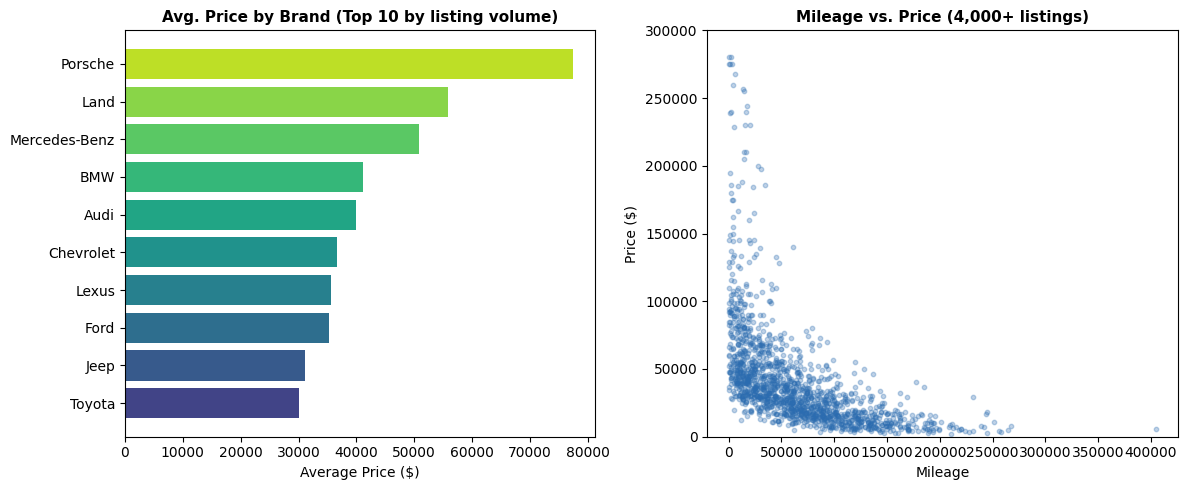

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

avg_price = (
    df_clean[df_clean['brand'].isin(top_brands)]
    .groupby('brand')['price_num']
    .mean()
    .sort_values(ascending=True)
)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(avg_price)))
axes[0].barh(avg_price.index, avg_price.values, color=colors)
axes[0].set_xlabel('Average Price ($)')
axes[0].set_title('Avg. Price by Brand (Top 10 by listing volume)', fontsize=11, fontweight='bold')

sample = df_clean.sample(min(1500, len(df_clean)), random_state=1)
axes[1].scatter(sample['mileage_num'], sample['price_num'], alpha=0.3, s=10, color='#2b6cb0')
axes[1].set_xlabel('Mileage')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Mileage vs. Price (4,000+ listings)', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 300_000)

plt.tight_layout()
plt.savefig('car_analysis_chart.png', dpi=150)
plt.show()